# IFN680 Project 5 — Forward Addition + Subtraction LLM

This notebook implements **Task 1** (Forward mode).

Shared infrastructure (tokenizer, dataset helpers, Transformer, batching, generation, evaluation utilities) lives in `project5_common.py`. This notebook defines the **Forward** experiment: normal left-to-right answer targets, training, and held-out evaluation.

During development, if you edit `project5_common.py` after importing it, either restart the kernel or run:

```python
import importlib
import project5_common as p5
importlib.reload(p5)
```

## 1. Environment and reproducibility

Project 5 should be run in the IFN680 GPU environment. Seeds make dataset generation repeatable; GPU training may still show small run-to-run differences.

In [1]:
import importlib
import random
import math
import time
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F
from tqdm.auto import tqdm

import project5_common as p5
importlib.reload(p5)

SEED = 680
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MODEL_PATH = Path("LLMForward.pth")
SPLITS_PATH = p5.SPLITS_PATH
TEST_DATA_PATH = p5.TEST_DATA_PATH

# Forward mode: identity target / restore transforms
TARGET_TRANSFORM = p5.forward_target
RESTORE_PREDICTION = p5.forward_target

Using device: cuda


## 2. Shared implementation (tokenizer)

Vocabulary and tokenisation are imported from `project5_common` so Forward and Reverse cannot drift.

In [2]:
tokenizer = p5.build_tokenizer()
ntokens = tokenizer.ntokens

print(f"Vocabulary ({ntokens} tokens): {tokenizer.vocab}")
print("Token IDs:", tokenizer.token_to_id)

Vocabulary (15 tokens): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']
Token IDs: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '+': 10, '-': 11, '=': 12, '[PAD]': 13, '[EOS]': 14}


### 2.1 Tokenizer sanity checks

In [3]:
examples = [
    "12+19=",
    "500-123=",
    "123-456=",
    "-333",
]

for text in examples:
    encoded = tokenizer.encode(text)
    decoded = tokenizer.decode(encoded)
    print(f"{text!r:12} -> {encoded} -> {decoded!r}")

'12+19='     -> [1, 2, 10, 1, 9, 12] -> '12+19='
'500-123='   -> [5, 0, 0, 11, 1, 2, 3, 12] -> '500-123='
'123-456='   -> [1, 2, 3, 11, 4, 5, 6, 12] -> '123-456='
'-333'       -> [11, 3, 3, 3] -> '-333'


## 3. Synthetic arithmetic dataset

Operands are non-negative integers with at most three digits. Each example is either addition or subtraction. Answers are stored in **normal** string form; Forward mode leaves them unchanged at batching time.

In [4]:
for operation in ["+", "-"]:
    for _ in range(3):
        print(p5.sample_datapoint(3, operation))

('627+501=', '1128')
('871+602=', '1473')
('136+830=', '966')
('818-848=', '-30')
('524-861=', '-337')
('557-360=', '197')


### 3.1 Carry and borrow descriptors

In [5]:
sanity_examples = [
    p5.convert_datapoint(12, 19, "+"),
    p5.convert_datapoint(123, 456, "+"),
    p5.convert_datapoint(500, 123, "-"),
    p5.convert_datapoint(123, 456, "-"),
]

for prompt, answer in sanity_examples:
    print(
        f"{prompt}{answer:<6} | "
        f"carries={p5.count_carries(prompt)} | "
        f"borrows={p5.count_borrows(prompt)}"
    )

12+19=31     | carries=1 | borrows=0
123+456=579    | carries=0 | borrows=0
500-123=377    | carries=0 | borrows=2
123-456=-333   | carries=0 | borrows=3


### 3.2 Balanced train / validation / test splits

Prefer the shared `project5_splits.pkl` so Forward and Reverse use identical arithmetic problems. The held-out test set is also written to `project5_test.pkl` for submission compatibility.

In [6]:
data_train, data_val, data_test = p5.load_or_create_splits(
    splits_path=SPLITS_PATH,
    test_path=TEST_DATA_PATH,
    seed=SEED,
)

p5.summarise_splits(data_train, data_val, data_test)
print(f"Splits file: {SPLITS_PATH.resolve()}")
print(f"Test file:   {TEST_DATA_PATH.resolve()}")

Train: 50,000
Validation: 10,000
Test: 10,000
Train/val overlap: 0
Train/test overlap: 0
Val/test overlap: 0
train: addition=25,000, subtraction=25,000
val  : addition=5,000, subtraction=5,000
test : addition=5,000, subtraction=5,000
Splits file: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project5/project5_splits.pkl
Test file:   /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project5/project5_test.pkl


### 3.3 Test-set arithmetic profile

In [7]:
addition_test = [sample for sample in data_test if "+" in sample[0]]
subtraction_test = [sample for sample in data_test if "-" in sample[0]]

addition_with_carry = [s for s in addition_test if p5.count_carries(s[0]) > 0]
addition_without_carry = [s for s in addition_test if p5.count_carries(s[0]) == 0]
subtraction_with_borrow = [s for s in subtraction_test if p5.count_borrows(s[0]) > 0]
subtraction_without_borrow = [s for s in subtraction_test if p5.count_borrows(s[0]) == 0]
negative_subtraction = [s for s in subtraction_test if int(s[1]) < 0]

print(f"Addition with carry:       {len(addition_with_carry):,}")
print(f"Addition without carry:    {len(addition_without_carry):,}")
print(f"Subtraction with borrow:   {len(subtraction_with_borrow):,}")
print(f"Subtraction without borrow:{len(subtraction_without_borrow):,}")
print(f"Negative subtraction:      {len(negative_subtraction):,}")

Addition with carry:       4,165
Addition without carry:    835
Subtraction with borrow:   4,200
Subtraction without borrow:800
Negative subtraction:      2,497


## 4–5. Positional encoding and causal Transformer

Architecture classes and hyperparameters are shared.

In [8]:
MODEL_CONFIG = p5.model_config(ntokens)
model = p5.TransformerModel(**MODEL_CONFIG).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

TransformerModel(
  (input_emb): Embedding(15, 128)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x CustomEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Linear(in_features=128, out_features=15, bias=True)
)
Parameters: 502,671
Trainable parameters: 502,671


/home/n10755306/ifn680/IFN680_Sam/Assessment1/Project5/project5_common.py:443: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


## 6. Autoregressive generation

Untrained sanity check using the shared `generate` helper.

In [9]:
model.eval()
prompt = "25-100="
prompt_tensor = torch.tensor(
    tokenizer.encode(prompt), dtype=torch.long
).view(-1, 1)

untrained_output = p5.generate(
    model, prompt_tensor, new_tokens=5, device=device
)[:, 0].detach().cpu().tolist()

print("Prompt:", prompt)
print("Untrained output:", tokenizer.decode(untrained_output))

Prompt: 25-100=
Untrained output: 25-100=77777


## 7. Padding and batching (Forward targets)

`get_batch` applies `TARGET_TRANSFORM` (identity in Forward mode) before tokenising answers.

In [10]:
batch_size = p5.DEFAULT_BATCH_SIZE

X, Y, length_prompts, length_answers = p5.get_batch(
    data_train,
    0,
    batch_size,
    tokenizer,
    TARGET_TRANSFORM,
)

print("Prompt batch shape:", X.shape)
print("Answer batch shape:", Y.shape)
print("Max prompt length:", length_prompts)
print("Max answer character length:", length_answers)

# Show a few decoded Forward targets from the first batch
for i in range(min(4, Y.shape[1])):
    prompt_tokens = [
        t for t in X[:, i].tolist()
        if t != tokenizer.token_to_id[p5.PAD_TOKEN]
    ]
    answer_tokens = [
        t for t in Y[:, i].tolist()
        if t not in {
            tokenizer.token_to_id[p5.PAD_TOKEN],
            tokenizer.token_to_id[p5.EOS_TOKEN],
        }
    ]
    print(
        f"{tokenizer.decode(prompt_tokens):<12} "
        f"target={tokenizer.decode(answer_tokens)}"
    )

Prompt batch shape: torch.Size([8, 100])
Answer batch shape: torch.Size([5, 100])
Max prompt length: 8
Max answer character length: 4
152-821=     target=-669
392-637=     target=-245
400+461=     target=861
360+683=     target=1043


## 8. Training-time evaluation

Token and sequence accuracy operate on **Forward** (normal-order) targets.

In [11]:
# Thin wrappers so the training cells stay readable and tutorial-like.

def evaluate_autoregressive(model, input_data, desc="Validation"):
    return p5.evaluate_autoregressive(
        model,
        input_data,
        tokenizer,
        device,
        target_transform=TARGET_TRANSFORM,
        batch_size=batch_size,
        desc=desc,
    )

## 9. Train the Forward model

The training loop remains visible in this notebook. Skip re-running if `LLMForward.pth` already exists and you only need evaluation.

In [12]:
learning_rate = 1e-3
epochs = 20

# Fresh model for the training run (tutorial-aligned optimiser).
model = p5.TransformerModel(**MODEL_CONFIG).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_token_accuracy": [],
    "val_token_accuracy": [],
    "train_sequence_accuracy": [],
    "val_sequence_accuracy": [],
}

best_val_sequence_accuracy = -1.0
best_epoch = 0

print(f"Training on: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Training examples: {len(data_train):,}")
print(f"Validation examples: {len(data_val):,}")
print(f"Batch size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Learning rate: {learning_rate}")


def train_epoch():
    model.train()
    total_loss = 0.0
    n_batches = 0
    random.shuffle(data_train)

    progress = tqdm(
        range(0, len(data_train), batch_size),
        total=math.ceil(len(data_train) / batch_size),
        desc="Training",
        leave=False,
    )

    for i in progress:
        prompts, target_answers, length_prompts, length_answers = p5.get_batch(
            data_train, i, batch_size, tokenizer, TARGET_TRANSFORM
        )
        prompts = prompts.to(device)
        target_answers = target_answers.to(device)

        input_tensor = torch.cat((prompts, target_answers), 0)
        optimizer.zero_grad()
        output, _, _ = model(input_tensor)

        output_answers = output[length_prompts - 1:-1, :, :].reshape(-1, ntokens)
        target_flat = target_answers.reshape(-1)
        loss = F.cross_entropy(output_answers, target_flat)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1
        progress.set_postfix(loss=f"{total_loss / n_batches:.4f}")

    return total_loss / n_batches


def validation_loss():
    model.eval()
    total_loss = 0.0
    n_batches = 0

    progress = tqdm(
        range(0, len(data_val), batch_size),
        total=math.ceil(len(data_val) / batch_size),
        desc="Validation loss",
        leave=False,
    )

    with torch.no_grad():
        for i in progress:
            prompts, target_answers, length_prompts, length_answers = p5.get_batch(
                data_val, i, batch_size, tokenizer, TARGET_TRANSFORM
            )
            prompts = prompts.to(device)
            target_answers = target_answers.to(device)
            input_tensor = torch.cat((prompts, target_answers), 0)
            output, _, _ = model(input_tensor)
            output_answers = output[length_prompts - 1:-1, :, :].reshape(-1, ntokens)
            target_flat = target_answers.reshape(-1)
            loss = F.cross_entropy(output_answers, target_flat)
            total_loss += loss.item()
            n_batches += 1

    return total_loss / n_batches


RUN_TRAINING = not MODEL_PATH.exists()
print(f"RUN_TRAINING = {RUN_TRAINING} (set True to force a retrain)")

if RUN_TRAINING:
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch()
        val_loss = validation_loss()

        train_token_acc, train_seq_acc = evaluate_autoregressive(
            model, data_train[:1000], desc=f"Epoch {epoch:02d} train accuracy"
        )
        val_token_acc, val_seq_acc = evaluate_autoregressive(
            model, data_val, desc=f"Epoch {epoch:02d} val accuracy"
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_token_accuracy"].append(train_token_acc)
        history["val_token_accuracy"].append(val_token_acc)
        history["train_sequence_accuracy"].append(train_seq_acc)
        history["val_sequence_accuracy"].append(val_seq_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"val_seq_acc={val_seq_acc:.4f}"
        )

        if val_seq_acc > best_val_sequence_accuracy:
            best_val_sequence_accuracy = val_seq_acc
            best_epoch = epoch
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"  saved checkpoint -> {MODEL_PATH}")

    elapsed = time.time() - start_time
    print(f"Training finished in {datetime.timedelta(seconds=int(elapsed))}")
    print(f"Best validation sequence accuracy: {best_val_sequence_accuracy:.4f} (epoch {best_epoch})")
else:
    print(f"Skipping training; existing checkpoint found at {MODEL_PATH}")

Training on: cuda
GPU: NVIDIA A16-4Q
Training examples: 50,000
Validation examples: 10,000
Batch size: 100
Epochs: 20
Learning rate: 0.001
RUN_TRAINING = True (set True to force a retrain)


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01 train accuracy:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 01 val accuracy:   0%|          | 0/100 [00:00<?, ?it/s]

...

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20 train accuracy:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 20 val accuracy:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20/20 | train_loss=0.0896 val_loss=0.0248 | val_seq_acc=0.9653
Training finished in 0:04:19
Best validation sequence accuracy: 0.9764 (epoch 19)


### 9.1 Training and validation convergence

Only plotted when a training run was executed in this session.

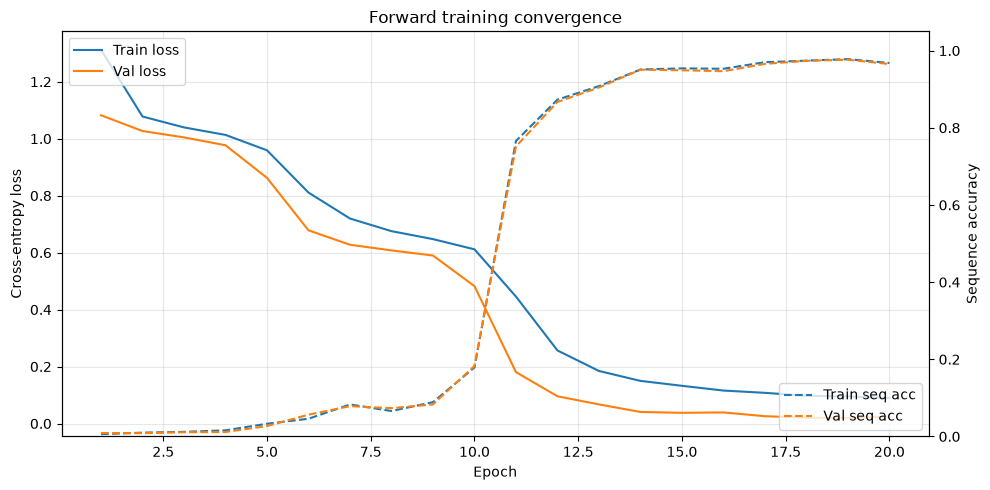

In [13]:
if history["train_loss"]:
    epoch_axis = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epoch_axis, history["train_loss"], label="Train loss")
    ax1.plot(epoch_axis, history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-entropy loss")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(epoch_axis, history["train_sequence_accuracy"], label="Train seq acc", linestyle="--")
    ax2.plot(epoch_axis, history["val_sequence_accuracy"], label="Val seq acc", linestyle="--")
    ax2.set_ylabel("Sequence accuracy")
    ax2.set_ylim(0, 1.05)
    ax2.legend(loc="lower right")

    plt.title("Forward training convergence")
    plt.tight_layout()
    plt.show()
else:
    print("No in-session training history to plot.")

## 10. Load the best validation checkpoint

In [14]:
model = p5.TransformerModel(**MODEL_CONFIG).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f"Loaded checkpoint: {MODEL_PATH.resolve()}")

Loaded checkpoint: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project5/LLMForward.pth


/home/n10755306/ifn680/IFN680_Sam/Assessment1/Project5/project5_common.py:443: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


## 11. Forward-model numeric inference

`RESTORE_PREDICTION` is the identity for Forward mode.

In [15]:
MAX_NEW_TOKENS = p5.DEFAULT_MAX_NEW_TOKENS

examples = [
    "12+19=",
    "999+999=",
    "500-123=",
    "500-278=",
    "123-456=",
    "0-999=",
]

for prompt in examples:
    predicted, restored, raw = p5.predict_sample(
        model,
        prompt,
        tokenizer,
        restore_prediction=RESTORE_PREDICTION,
        max_new_tokens=MAX_NEW_TOKENS,
        device=device,
    )
    a, operation, b = p5.parse_prompt(prompt)
    actual = a + b if operation == "+" else a - b
    status = "CORRECT" if predicted == actual else "WRONG"
    print(
        f"{prompt:<10} predicted={str(predicted):<6} "
        f"raw={raw!r:<8} actual={actual:<6} {status}"
    )

12+19=     predicted=11033  raw='11033'  actual=31     WRONG
999+999=   predicted=1998   raw='1998'   actual=1998   CORRECT
500-123=   predicted=377    raw='377'    actual=377    CORRECT
500-278=   predicted=222    raw='222'    actual=222    CORRECT
123-456=   predicted=-333   raw='-333'   actual=-333   CORRECT
0-999=     predicted=-8106  raw='-8106'  actual=-999   WRONG


## 12. Formal Forward-model test evaluation

Primary metric: exact numeric equality on the shared held-out test set.

In [16]:
test_records = p5.predict_dataset(
    model,
    data_test,
    tokenizer,
    restore_prediction=RESTORE_PREDICTION,
    batch_size=batch_size,
    max_new_tokens=MAX_NEW_TOKENS,
    device=device,
)

addition_records = p5.subset(test_records, lambda r: r["operation"] == "+")
subtraction_records = p5.subset(test_records, lambda r: r["operation"] == "-")

print(f"Overall exact numeric accuracy: {p5.accuracy(test_records):.2%}")
print(f"Addition accuracy:             {p5.accuracy(addition_records):.2%}")
print(f"Subtraction accuracy:          {p5.accuracy(subtraction_records):.2%}")

Predict:   0%|          | 0/100 [00:00<?, ?it/s]

Overall exact numeric accuracy: 97.24%
Addition accuracy:             99.12%
Subtraction accuracy:          95.36%


### 12.1 Digit-position and sign accuracy

In [17]:
print(
    f"{'Metric':<15}"
    f"{'All':>16}"
    f"{'Addition':>20}"
    f"{'Subtraction':>20}"
)
print("-" * 71)

def format_metric(acc, n):
    if acc is None:
        return "N/A"
    return f"{acc * 100:.2f}% (n={n})"

for name, position in p5.DIGIT_POSITIONS.items():
    all_acc, all_n = p5.digit_position_accuracy(test_records, position)
    add_acc, add_n = p5.digit_position_accuracy(addition_records, position)
    sub_acc, sub_n = p5.digit_position_accuracy(subtraction_records, position)
    print(
        f"{name:<15}"
        f"{format_metric(all_acc, all_n):>16}"
        f"{format_metric(add_acc, add_n):>20}"
        f"{format_metric(sub_acc, sub_n):>20}"
    )

sign_correct = 0
sign_total = 0
negative_exact_correct = 0
negative_total = 0

for record in subtraction_records:
    actual = record["actual"]
    predicted = record["predicted"]
    if predicted is not None:
        sign_correct += (actual < 0) == (predicted < 0)
        sign_total += 1
    if actual < 0:
        negative_total += 1
        if predicted == actual:
            negative_exact_correct += 1

print()
print(f"Subtraction sign accuracy: {sign_correct / max(sign_total, 1) * 100:.2f}%")
print(
    f"Negative-result exact accuracy: "
    f"{negative_exact_correct / max(negative_total, 1) * 100:.2f}%"
)

Metric                      All            Addition         Subtraction
-----------------------------------------------------------------------
Units          98.59% (n=10000)     99.78% (n=5000)     97.40% (n=5000)
Tens            98.81% (n=9892)     99.52% (n=5000)     98.08% (n=4892)
Hundreds        99.68% (n=9004)     99.72% (n=4970)     99.63% (n=4034)
Thousands      100.00% (n=2502)    100.00% (n=2502)                 N/A

Subtraction sign accuracy: 99.98%
Negative-result exact accuracy: 96.84%


### 12.2 Carry and borrow robustness

In [18]:
add_no_carry = p5.subset(addition_records, lambda r: r["carry_count"] == 0)
add_with_carry = p5.subset(addition_records, lambda r: r["carry_count"] > 0)
sub_no_borrow = p5.subset(subtraction_records, lambda r: r["borrow_count"] == 0)
sub_with_borrow = p5.subset(subtraction_records, lambda r: r["borrow_count"] > 0)

print("Addition")
print(f"  No carry:    n={len(add_no_carry):4d}, accuracy={p5.accuracy(add_no_carry):.2%}")
print(f"  With carry:  n={len(add_with_carry):4d}, accuracy={p5.accuracy(add_with_carry):.2%}")
print()
print("Subtraction")
print(f"  No borrow:   n={len(sub_no_borrow):4d}, accuracy={p5.accuracy(sub_no_borrow):.2%}")
print(f"  With borrow: n={len(sub_with_borrow):4d}, accuracy={p5.accuracy(sub_with_borrow):.2%}")

Addition
  No carry:    n= 835, accuracy=98.92%
  With carry:  n=4165, accuracy=99.16%

Subtraction
  No borrow:   n= 800, accuracy=91.62%
  With borrow: n=4200, accuracy=96.07%


### 12.3 Inspect representative errors

In [19]:
errors = [r for r in test_records if not r["exact"]]
print(f"Total errors: {len(errors):,} / {len(test_records):,}")
print()
for record in errors[:20]:
    print(
        f"{record['prompt']:<12} "
        f"pred={str(record['predicted']):<6} "
        f"actual={record['actual']:<6} "
        f"raw={record['raw_prediction']!r:<8} "
        f"carry={record['carry_count']} "
        f"borrow={record['borrow_count']}"
    )

Total errors: 276 / 10,000

817-819=     pred=-4     actual=-2     raw='-4'     carry=0 borrow=3
948-944=     pred=5      actual=4      raw='5'      carry=0 borrow=0
689-689=     pred=1      actual=0      raw='1'      carry=0 borrow=0
159-161=     pred=-1     actual=-2     raw='-1'     carry=0 borrow=2
806-991=     pred=-186   actual=-185   raw='-186'   carry=0 borrow=2
640-641=     pred=-3     actual=-1     raw='-3'     carry=0 borrow=3
151-139=     pred=13     actual=12     raw='13'     carry=0 borrow=1
696-881=     pred=-186   actual=-185   raw='-186'   carry=0 borrow=1
231-224=     pred=1      actual=7      raw='1'      carry=0 borrow=1
492-488=     pred=1      actual=4      raw='1'      carry=0 borrow=1
256+194=     pred=449    actual=450    raw='449'    carry=2 borrow=0
789+2=       pred=781    actual=791    raw='781'    carry=1 borrow=0
703-653=     pred=40     actual=50     raw='40'     carry=0 borrow=1
211-217=     pred=-5     actual=-6     raw='-5'     carry=0 borrow=3
457-45

## 13. Task 1 summary

Forward mode uses shared Project 5 infrastructure with **normal-order** answer targets.

Artefacts for later tasks:

- `LLMForward.pth`
- `project5_test.pkl` / `project5_splits.pkl`

Next: `LLMReverse.ipynb` changes only the target transform (`answer[::-1]`) and restores generated answers before numeric parsing.